# Attention-based Unet for Segmentation

We regrouped the results we obtained during this project on this notebook in order to explain the way we worked and the results we got.

P.S: We trained the models on Google Colab because it was quicker so we only have the results to show on this notebook.

P.S 2: When we will refer to the loss, we refer in fact to the combined loss we defined in the losses.py file. This is the loss function we used to train our models.

In [ ]:
%load_ext autoreload
%autoreload 2
from models import U_Net, AttU_Net
from train import train_2D, test_2D, test_3D
# Import of the libraries and functions
from utils import show_input_mask, compare_predictions_ground_truth, prepare_data, graph, predict_volume, load_slice, GradCAM, overlay_cam, overlay_cam_multi, saliency_map
from torch.utils.data import TensorDataset, DataLoader
import nibabel as nib
import matplotlib.pyplot as plt
import torch

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


We can start by showing an input image and an output mask to visualize the kind of results we want to obtain.

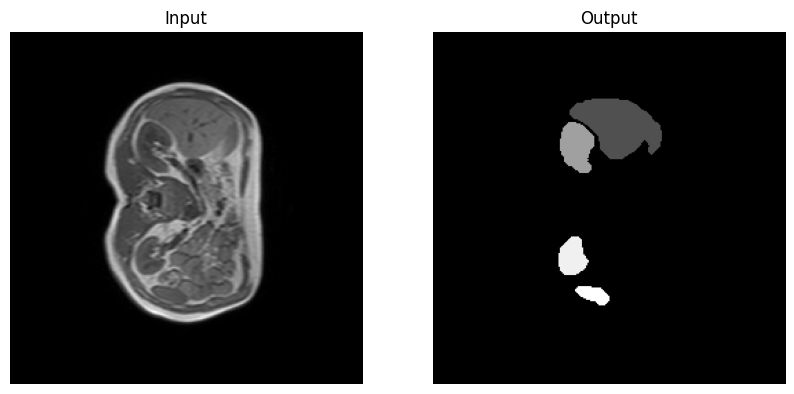

In [3]:
show_input_mask(input_path="data/MR-dataset/01-T1DUALin-src.nii.gz", output_path="data/MR-dataset/01-T1DUAL-mask.nii.gz", slice_idx=20)

## Training on different sets

At the very beginning, we did the split of the data directly in the training function :

In [ ]:
# This function is not valid anymore as we modified it to take directly the train_loader and the validation_loader in parameters
# However, we still wanted to show it because we obtained interesting results with it

train_loss, validation_losses, test_loss = train_2D(
    model= U_Net(1, 5),
    name ="U_Net_weights30",
    train_size=14,
    validation_size=2,
    test_size=4,
    num_epochs=30,
    lr=1e-4,
    max_no_upgrade=100
)

The losses obtained with this function for the U-Net were :

![](loss_images/U_Net_30_epochs.png)

Unfortunately, we no longer have the loss value for this U-Net on the test set. Moreover, even if we did, it wouldn’t be very informative, since we wouldn’t be able to compare it with the Attention U-Net’s loss due to differences in the test sets.

In [ ]:
# This function is not valid anymore as we modified it to take directly the train_loader and the validation_loader in parameters
# However, we still wanted to show it because we obtained interesting results with it
# We provide the code we used to get the results so that you can have access to the parameters we used

train_loss, validation_losses, test_loss = train_2D(
    model= AttU_Net(1, 5),
    name ="Att_U_Net_weights30",
    train_size=14,
    validation_size=2,
    test_size=4,
    num_epochs=30,
    lr=1e-4,
    max_no_upgrade=100
)

The losses obtained with this function for the Attention U-Net were :

![](loss_images/Att_U_Net_30.png)

And the loss on the test set was 0.1648. Therefore, we can think that the Attention U-Net is much better than the U-Net as the validation loss tends toward 0.1 for the Attention U-Net while it remains at 0.2 for the U-Net. However, as we did not use the same sets to compute the models and the losses, we can't make any conclusion at this point.

## Training on the same sets

In order to be able to compare the performances between the U-Net and the Attention U-Net, we define the training, validation and test set outside the training function such that we train the models with the same sets

In [2]:
(X_train_tensor,
X_validation_tensor,
X_test_tensor,
y_train_tensor,
y_validation_tensor,
y_test_tensor,
X_test_3D,
y_test_3D) = prepare_data(train_size = 14, validation_size=2, rand = True, data_path="data")

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)

validation_dataset = TensorDataset(X_validation_tensor, y_validation_tensor)
validation_loader = DataLoader(validation_dataset, batch_size=4, shuffle=True)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=True)

X_train.shape :  (459, 1, 256, 256)
X_validation.shape :  (61, 1, 256, 256)
X_test.shape :  (127, 1, 256, 256)


Then, we train the U-Net with the training, validation and test sets we defined in the previous cell.

In [ ]:
train_loss_u_net, validation_losses_u_net = train_2D(
    model=U_Net(1, 5),
    train_loader=train_loader,
    validation_loader=validation_loader,
    name ="U_Net_weights30_V4",
    num_epochs=30,
    lr=1e-4,
    max_no_upgrade=100
)

We also train the Attention U-Net with the same sets.

In [ ]:
train_loss_attention_u_net, validation_losses_attention_u_net = train_2D(
    model=AttU_Net(1, 5),
    train_loader=train_loader,
    validation_loader=validation_loader,
    name ="Att_U_Net_weights30_V4",
    num_epochs=30,
    lr=1e-4,
    max_no_upgrade=100
)

And we plot the loss figures to compare the performances of the two models.

![](loss_images/Loss_comparison_between_U-net_and_Attention-U-Net_V4.png)

We notice that the loss functions from the U-Net and the Attention U-Net are very close. We also see that the loss is generally higher for the Attention U-Net at the beginning of the training. The two losses tends towards the same limits and the difference of performances between the two models are not clearly visible.

To compare the performances of the two models, we can compute the combined loss we used during the training on the test sets.

In [ ]:
test_2D(U_Net(1,5), test_loader, "U_Net_weights30_V4")
test_2D(AttU_Net(1,5), test_loader, "Att_U_Net_weights30_V4")

We obtained :

Loss on test dataset for the U-Net: 0.1105

Dice per class on test dataset for the U-Net: [0.99486638 0.90845117 0.74504915 0.74103333 0.68104184]

Loss on test dataset for the Attention U-Net: 0.1203

Dice per class on test dataset for the Attention U-Net: [0.99485236 0.86560572 0.74307976 0.73175285 0.65622234]

So what we notice is that we have better results for the Attention U-Net, based on the combined loss. However, to we will use another metric, which is the dice 3D to see i

In [4]:
test_3D(
    model = U_Net(1, 5),
    X_test_3D = X_test_3D,
    y_test_3D = y_test_3D,
    name = "models/U_Net_weights50"
)

tensor([0.9966, 0.9364, 0.8874, 0.8900, 0.9034])

When we compare the losses on the test dataset for the two models, we notice that we have a slightly higher loss for the Attention U-Net, which seems confusing as the Attention U-Net is supposed to improve the performance. We also notice that the value of the loss is around 0.075 while we had a loss of approximately 0.2 on the training set for the models so this is also pretty weird.

## Visualisation of the volumes computed

In order to visualize the results obtained with our models, we show the input image, the target mask and the prediction we get.

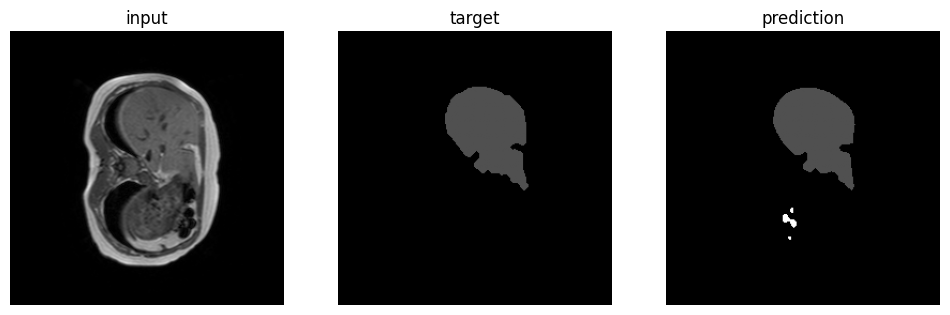

IntSlider(value=24, description='Slice', max=34)

In [ ]:
compare_predictions_ground_truth(U_Net(1,5), "weights/U_Net_weights30_V3.pth", "data/MR-dataset/34-T1DUALin-src.nii.gz", "data/MR-dataset/34-T1DUAL-mask.nii.gz")

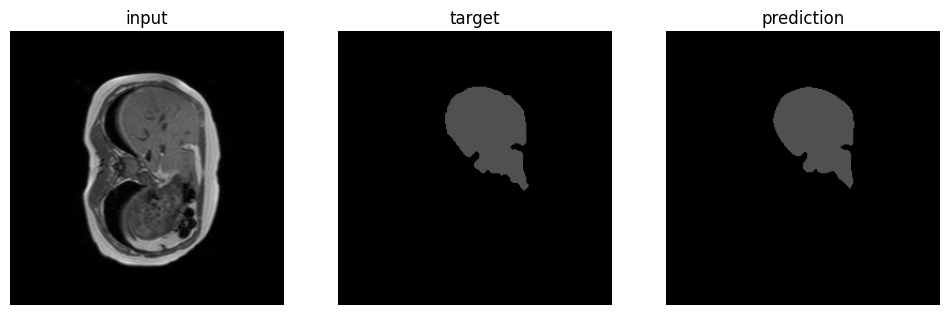

IntSlider(value=24, description='Slice', max=34)

In [11]:
compare_predictions_ground_truth(AttU_Net(1,5), "weights/Att_U_Net_weights30_V3.pth", "data/MR-dataset/34-T1DUALin-src.nii.gz", "data/MR-dataset/34-T1DUAL-mask.nii.gz")

Thanks to the slider, we can see that both models provide reasonably good volume predictions for the organs. However, at slice 24 for example, the U-Net still predicts the presence of an organ in the lower part of the image, even though the ground-truth mask shows that the organ is no longer present in that region. The Attention U-Net, on the other hand, avoids this error and correctly stops predicting the organ at the same time as the ground-truth mask.

### Training of U_net and Attentinon U_net models over 50 epochs

We decided to train the models on more epochs to see if there will be a difference.

![Train loss](loss_images/Train_Loss_comparison_between_U-net_and_Attention-U-Net_50_epochs.png)
![Validation loss](loss_images/Validation_Loss_comparison_between_U-net_and_Attention-U-Net_50_epochs.png)


The loss curves show that there is no significant difference between the loss at epoch 50 and the loss at epoch 30. This suggests that continuing the training further is not particularly useful, as the models have already reached their optimal performance.

In [13]:
test_loss,dice_classes = test_2D(
    model=U_Net(1, 5),
    test_loader=test_loader,
    name ="models/U_Net_weights50"
)
#Loss on test dataset: 0.1841
#Dice per class on test dataset: [0.99417681 0.86107182 0.56421426 0.53450103 0.5273771 ]

Loss on test dataset: 0.1841
Dice per class on test dataset: [0.99417681 0.86107182 0.56421426 0.53450103 0.5273771 ]


In [14]:
test_loss,dice_classes = test_2D(
    model=AttU_Net(1, 5),
    test_loader=test_loader,
    name ="models/Att_U_Net_weights50"
)
#Loss on test dataset: 0.1621
#Dice per class on test dataset: [0.99505883 0.87836151 0.53795041 0.61200625 0.60462299]

#Loss on test dataset: 0.1621
Dice per class on test dataset: [0.99505883 0.87836151 0.53795041 0.61200625 0.60462299]


In [ ]:
test_3D(
    model = U_Net(1, 5),
    X_test_3D = X_test_3D,
    y_test_3D = y_test_3D,
    name = "weights/U_Net_weights30_V4"
)

#tensor([0.9943, 0.9125, 0.7876, 0.7674, 0.7605])

In [ ]:
test_3D(
    model = AttU_Net(1, 5),
    X_test_3D = X_test_3D,
    y_test_3D = y_test_3D,
    name = "models/Att_U_Net_weights50"
)

#tensor([0.9950, 0.9150, 0.7191, 0.8026, 0.8353])

tensor([0.9950, 0.9150, 0.7191, 0.8026, 0.8353])

When we look at the dice loss on the 3D volumes, we see that we have better performances for 3 organs over 4 with the Attention U-Net. Thus, the use of attention mechanisms is useful and allows to get better performances on this segmentation task.

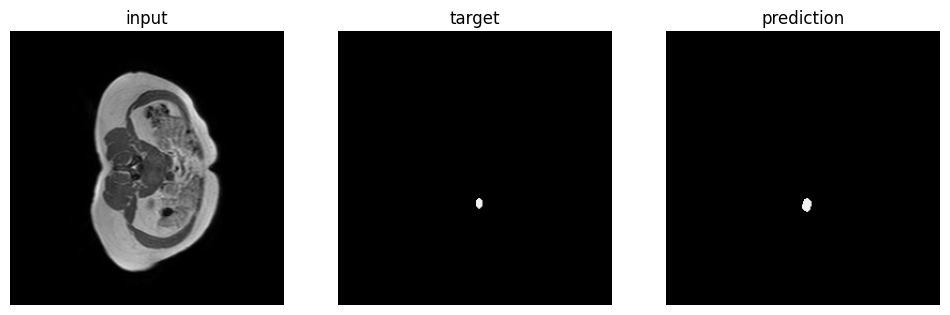

IntSlider(value=0, description='Slice', max=34)

In [ ]:
compare_predictions_ground_truth(U_Net(1,5), "models/U_Net_weights50.pth", "data/MR-dataset/34-T1DUALin-src.nii.gz", "data/MR-dataset/34-T1DUAL-mask.nii.gz")

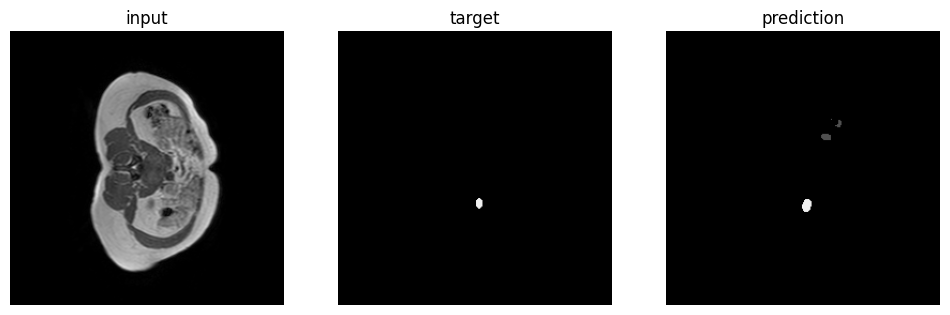

IntSlider(value=0, description='Slice', max=34)

In [12]:
compare_predictions_ground_truth(AttU_Net(1,5), "models/Att_U_Net_weights50.pth", "data/MR-dataset/34-T1DUALin-src.nii.gz", "data/MR-dataset/34-T1DUAL-mask.nii.gz")

## Visualization of saliency maps

To visualize the regions that contribute most to the organ segmentation, we display the saliency maps obtained by computing the gradients of the model’s output with respect to the input image.

We used two methods to compute the saliency maps: a classic one using the gradients of the model's output with respect to the input image, and another one using GradCam.

In [12]:
nifti_out, volume = predict_volume(U_Net(1,5), "U_Net_weights30.pth", "data/MR-dataset/01-T1DUALin-src.nii.gz")

In [13]:
save_path = "reconstructed_volumes/predicted_mask_01-T1DUAL_U_Net.nii.gz"
nib.save(nifti_out, save_path)

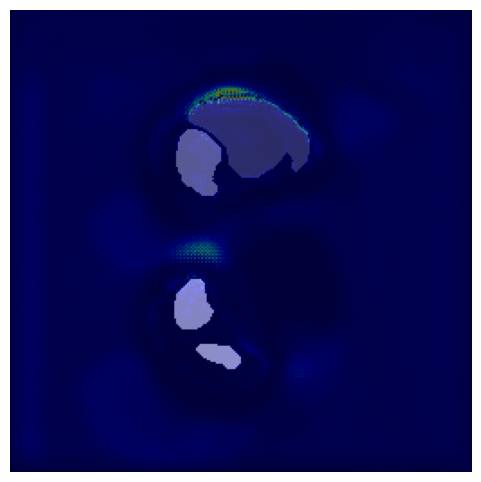

In [22]:
model = U_Net(1,5)
model.load_state_dict(torch.load("weights/U_Net_weights30_V4.pth", map_location = torch.device('cpu')))

image = load_slice("data/MR-dataset/01-T1DUAL-mask.nii.gz", 20)

grad = saliency_map(model, image, class_idx=2)

overlay_cam(image, grad)

In [ ]:
def overlay_cam_multi(image, cams, titles=None):
    """
    Affiche côte à côte plusieurs CAMs (ou saliency maps)
    en suivant le style de la fonction overlay_cam.

    image : tensor de l'image (1,H,W)
    cams  : liste de tensors de saliency maps
    titles : liste de titres optionnels
    """
    img = image.squeeze().cpu().numpy()

    n = len(cams)
    plt.figure(figsize=(4*n, 4))

    for i in range(n):
        cam = cams[i].detach().cpu().numpy()

        plt.subplot(1, n, i+1)
        plt.imshow(img, cmap="gray")
        plt.imshow(cam, cmap="jet", alpha=0.45)
        if titles is not None:
            plt.title(titles[i])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

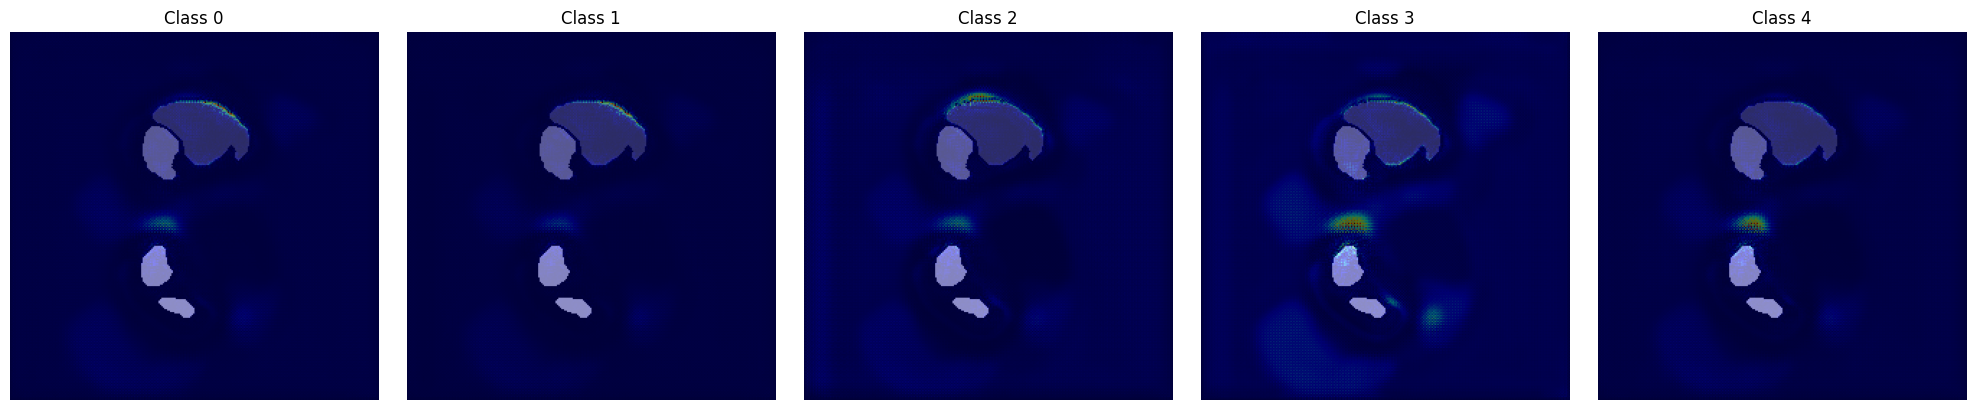

In [32]:
# Calcul des saliency maps pour les 5 classes
cams = []
for class_idx in range(5):
    grad = saliency_map(model, image, class_idx=class_idx)
    cams.append(grad)

# Affichage
overlay_cam_multi(image, cams, titles=[f"Class {i}" for i in range(5)])

When we look at the saliency maps for each of the class, we see that the organs are well 

c:\Users\gwend\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\nn\modules\module.py:1866: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


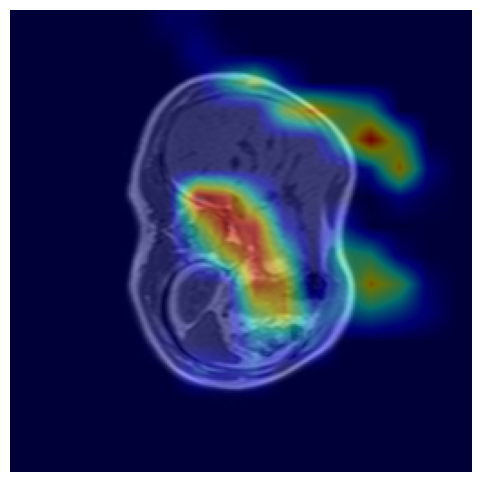

In [13]:
model = U_Net(1,5)
model.load_state_dict(torch.load("weights/U_Net_weights30_V4.pth", map_location = torch.device('cpu')))

target_layer = model.Conv5

cam = GradCAM(model, target_layer)

image = load_slice("data/MR-dataset/01-T1DUALin-src.nii.gz", 30)

# image : (1,1,H,W)
heatmap = cam(image, class_idx=3)

overlay_cam(image, heatmap)

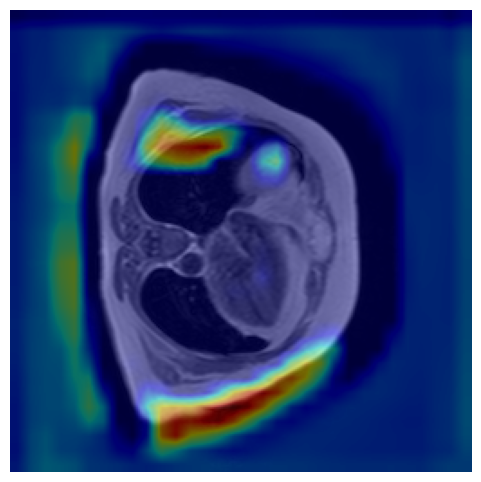

In [8]:
model = AttU_Net(1,5)
model.load_state_dict(torch.load("weights/Att_U_Net_weights30_V4.pth", map_location = torch.device('cpu')))

target_layer = model.Att5

cam = GradCAM(model, target_layer)

image = load_slice("data/MR-dataset/04-T1DUALin-src.nii.gz", 20)

# image : (1,1,H,W)
heatmap = cam(image, class_idx=2)

overlay_cam(image, heatmap)

In [71]:
nifti_out, volume = predict_volume(AttU_Net(1,5), "models/attU_Net_weights100.pth","data/MR-dataset/01-T1DUALin-src.nii.gz")

<class 'numpy.ndarray'>
(35, 256, 256)


In [6]:
model = AttU_Net(1,5)
model.load_state_dict(torch.load("weights/U_Net_weights30_V4.pth", map_location = torch.device('cpu')))

image = load_slice("data/MR-dataset/01-T1DUAL-mask.nii.gz", 20)

grad = saliency_map(model, image, class_idx=3)

overlay_cam(image, grad)

RuntimeError: Error(s) in loading state_dict for AttU_Net:
	Missing key(s) in state_dict: "Att5.W_g.0.weight", "Att5.W_g.0.bias", "Att5.W_g.1.weight", "Att5.W_g.1.bias", "Att5.W_g.1.running_mean", "Att5.W_g.1.running_var", "Att5.W_x.0.weight", "Att5.W_x.0.bias", "Att5.W_x.1.weight", "Att5.W_x.1.bias", "Att5.W_x.1.running_mean", "Att5.W_x.1.running_var", "Att5.psi.0.weight", "Att5.psi.0.bias", "Att5.psi.1.weight", "Att5.psi.1.bias", "Att5.psi.1.running_mean", "Att5.psi.1.running_var", "Att4.W_g.0.weight", "Att4.W_g.0.bias", "Att4.W_g.1.weight", "Att4.W_g.1.bias", "Att4.W_g.1.running_mean", "Att4.W_g.1.running_var", "Att4.W_x.0.weight", "Att4.W_x.0.bias", "Att4.W_x.1.weight", "Att4.W_x.1.bias", "Att4.W_x.1.running_mean", "Att4.W_x.1.running_var", "Att4.psi.0.weight", "Att4.psi.0.bias", "Att4.psi.1.weight", "Att4.psi.1.bias", "Att4.psi.1.running_mean", "Att4.psi.1.running_var", "Att3.W_g.0.weight", "Att3.W_g.0.bias", "Att3.W_g.1.weight", "Att3.W_g.1.bias", "Att3.W_g.1.running_mean", "Att3

In [22]:
from losses import dice_per_class_3D
import torch
img = nib.load("data/MR-dataset/01-T1DUAL-mask.nii.gz")
data = img.get_fdata()

data = torch.tensor(data, dtype=torch.float32)
volume = torch.tensor(volume, dtype=torch.float32)

data = data.permute(2,0,1)
print(volume.shape)
volume = volume.permute(2,0,1)

unique_vals = torch.unique(data)


# Appliquer le mapping
mapped = torch.bucketize(data, unique_vals)

print(mapped.shape)
print(volume.shape)

torch.Size([256, 256, 35])
torch.Size([35, 256, 256])
torch.Size([35, 256, 256])


In [23]:
dice = dice_per_class_3D(volume, mapped, 5)

print(dice)

tensor([0.0535, 0.9860, 0.2654, 0.4173, 0.2606])
